# Energy Price EDA
Exploratory Data Analysis — German Day-Ahead Electricity Prices (2019–2026)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/df_final.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
print(f'Shape: {df.shape}')
print(f'Range: {df.timestamp.min()} → {df.timestamp.max()}')
df.head(3)

Shape: (62728, 30)
Range: 2019-01-08 00:00:00 → 2026-03-05 22:00:00


,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,...,is_hol_or_week,total_generation,net_export,coal_generation,gas_generation,nuclear_generation,actual_wind_offshore,actual_wind_onshore,actual_solar,actual_load
0,2019-01-08 00:00:00,17.94,51472.75,4520.75,32832.0,0.0,0,1,1,5.0000,...,False,68405.50,12433.0,10497.25,3789.0,8675.50,3505.75,33982.0,0.0,54342.75
1,2019-01-08 01:00:00,20.91,49815.00,4397.00,33236.5,0.0,1,1,1,5.1250,...,False,68068.25,12605.0,10096.25,3614.0,8958.50,3552.00,33866.0,0.0,52541.75
2,2019-01-08 02:00:00,7.78,49241.75,4379.00,33473.5,0.0,2,1,1,4.9875,...,False,67413.75,12479.0,9980.50,3599.0,8720.75,3463.75,33839.5,0.0,51658.75


---
## 1. Price Distribution

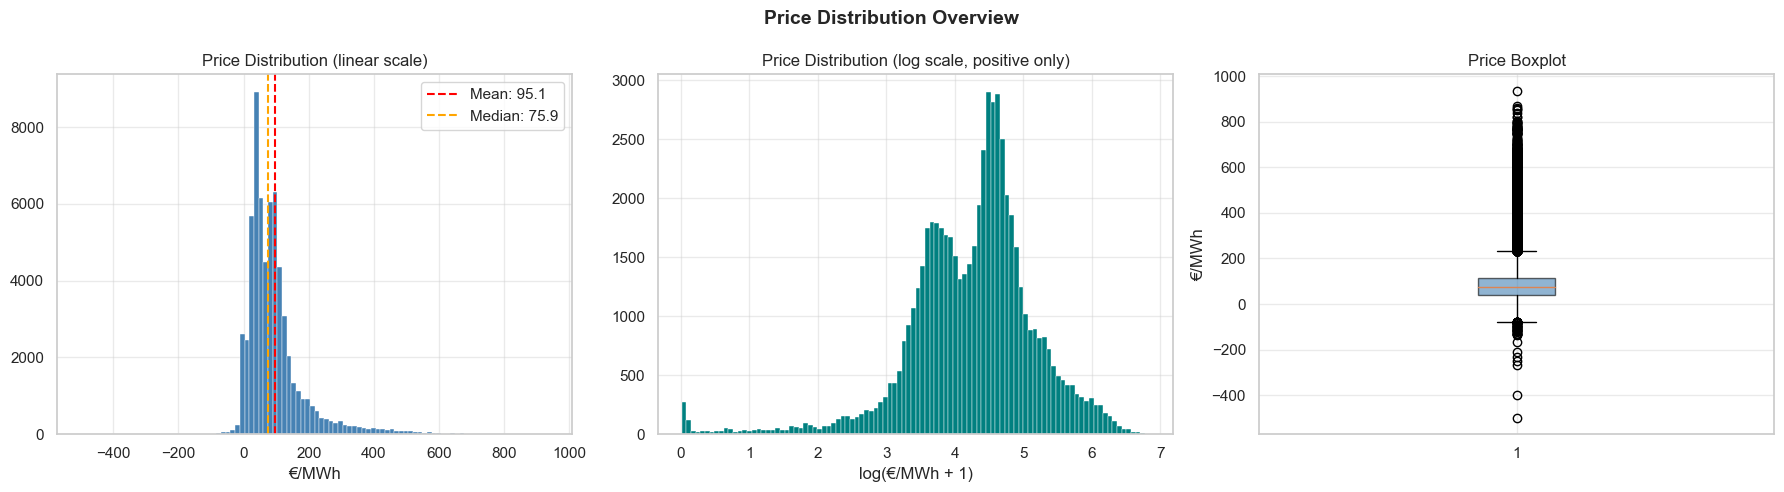

count    62728.00
mean        95.12
std         92.90
min       -500.00
25%         38.10
50%         75.90
75%        115.27
max        936.28
Name: price, dtype: float64

Negative prices: 2037 (3.2%)
Zero prices:     189
Prices > 300:    2655 (4.2%)


In [4]:
# creating three graphs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', label=f"Mean: {df['price'].mean():.1f}")
axes[0].axvline(df['price'].median(), color='orange', linestyle='--', label=f"Median: {df['price'].median():.1f}")
axes[0].set_title('Price Distribution (linear scale)')
axes[0].set_xlabel('€/MWh')
axes[0].legend()

# Log scale histogram (positive prices only)
pos_prices = df.loc[df['price'] > 0, 'price']
axes[1].hist(np.log1p(pos_prices), bins=100, color='teal', edgecolor='white', linewidth=0.3)
axes[1].set_title('Price Distribution (log scale, positive only)')
axes[1].set_xlabel('log(€/MWh + 1)')

# Boxplot
axes[2].boxplot(df['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[2].set_title('Price Boxplot')
axes[2].set_ylabel('€/MWh')

plt.suptitle('Price Distribution Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(df['price'].describe().round(2))
print(f"\nNegative prices: {(df['price'] < 0).sum()} ({(df['price'] < 0).mean()*100:.1f}%)")
print(f"Zero prices:     {(df['price'] == 0).sum()}")
print(f"Prices > 300:    {(df['price'] > 300).sum()} ({(df['price'] > 300).mean()*100:.1f}%)")

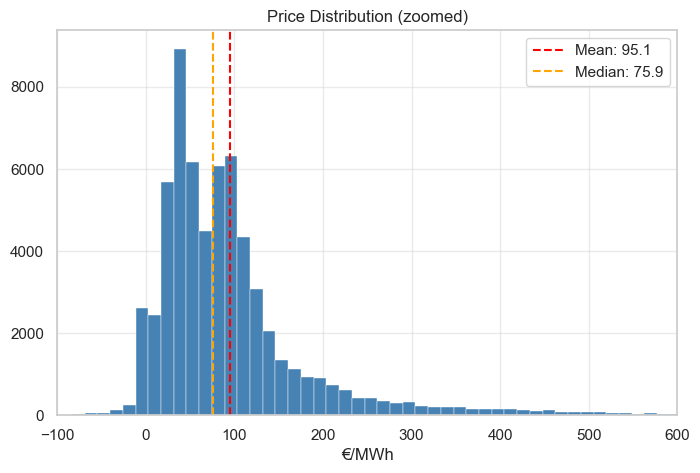

In [5]:
# zoomed in price distribution
plt.figure(figsize=(8,5))

plt.hist(df['price'], bins=100, color='steelblue', edgecolor='white', linewidth=0.3)

plt.axvline(df['price'].mean(), color='red', linestyle='--', label=f"Mean: {df['price'].mean():.1f}")
plt.axvline(df['price'].median(), color='orange', linestyle='--', label=f"Median: {df['price'].median():.1f}")

plt.title("Price Distribution (zoomed)")
plt.xlabel("€/MWh")

plt.xlim(-100, 600)

plt.legend()
plt.show()

In [6]:
# The electricity price distribution is strongly right-skewed, indicating occasional extreme price spikes
# Negative electricity prices occur during periods of excess generation

---
## 2. Price Time Series — Full History

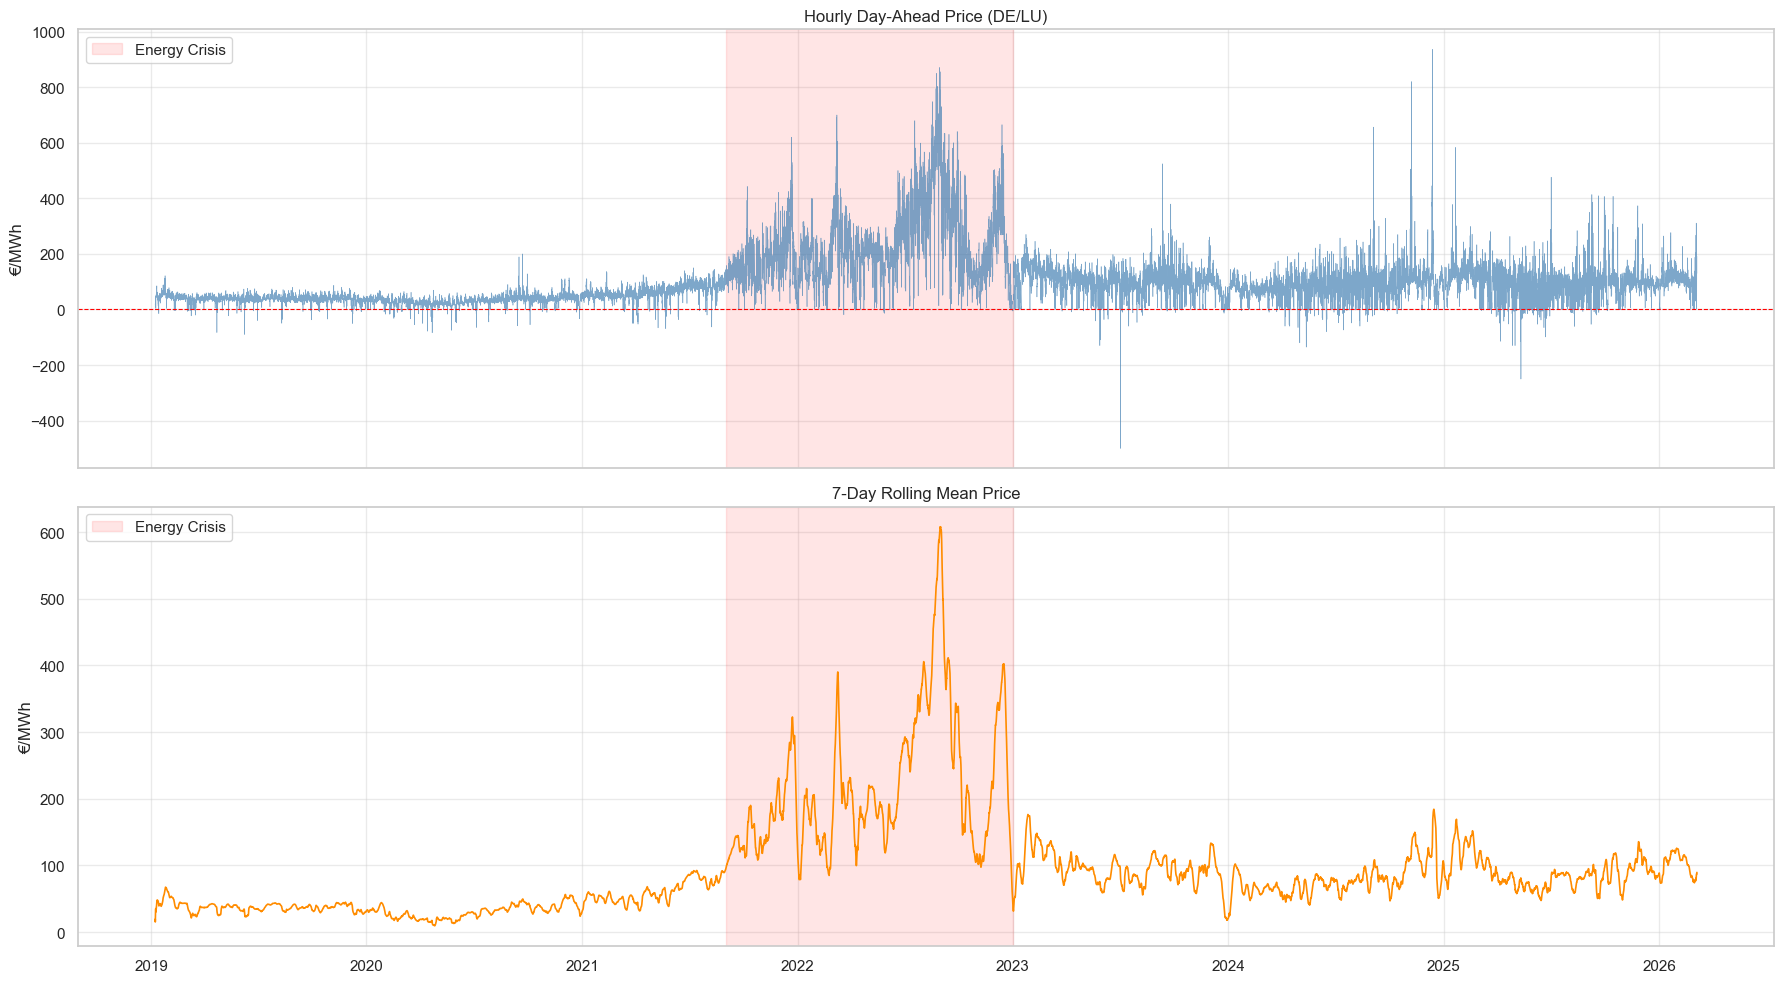

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Raw hourly prices
axes[0].plot(df['timestamp'], df['price'], color='steelblue', linewidth=0.4, alpha=0.7)
axes[0].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[0].set_title('Hourly Day-Ahead Price (DE/LU)')
axes[0].set_ylabel('€/MWh')

# 7-day rolling mean
roll = df.set_index('timestamp')['price'].rolling('7D').mean()
axes[1].plot(roll.index, roll.values, color='darkorange', linewidth=1.2)
axes[1].set_title('7-Day Rolling Mean Price')
axes[1].set_ylabel('€/MWh')

# Mark energy crisis
for ax in axes:
    ax.axvspan(pd.Timestamp('2021-09-01'), pd.Timestamp('2023-01-01'),
               alpha=0.1, color='red', label='Energy Crisis')
    ax.legend(loc='upper left')

axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

---
## 3. Seasonality Analysis

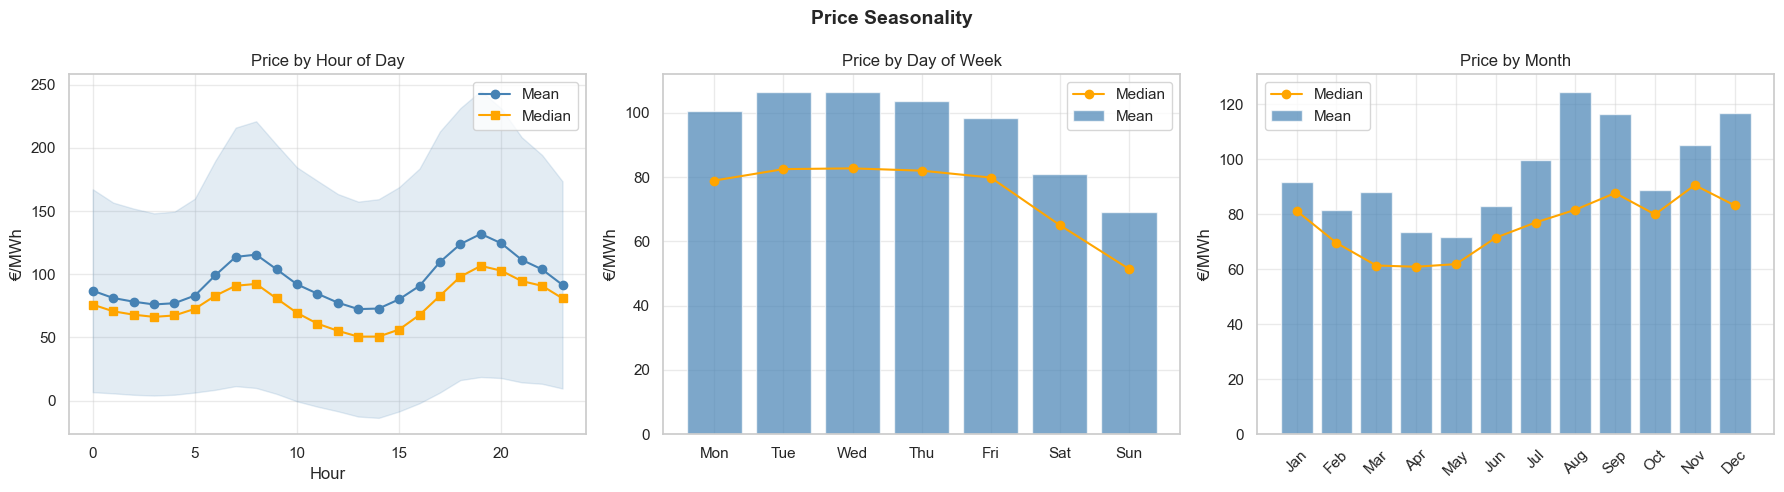

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By hour
hour_stats = df.groupby('hour')['price'].agg(['mean', 'median', 'std'])
axes[0].plot(hour_stats.index, hour_stats['mean'], marker='o', label='Mean', color='steelblue')
axes[0].plot(hour_stats.index, hour_stats['median'], marker='s', label='Median', color='orange')
axes[0].fill_between(hour_stats.index,
                     hour_stats['mean'] - hour_stats['std'],
                     hour_stats['mean'] + hour_stats['std'],
                     alpha=0.15, color='steelblue')
axes[0].set_title('Price by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('€/MWh')
axes[0].legend()

# By day of week
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_stats = df.groupby('day_of_week')['price'].agg(['mean', 'median'])
axes[1].bar(dow_labels, dow_stats['mean'], color='steelblue', alpha=0.7, label='Mean')
axes[1].plot(dow_labels, dow_stats['median'], marker='o', color='orange', label='Median')
axes[1].set_title('Price by Day of Week')
axes[1].set_ylabel('€/MWh')
axes[1].legend()

# By month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_stats = df.groupby('month')['price'].agg(['mean', 'median'])
axes[2].bar(month_labels, month_stats['mean'], color='steelblue', alpha=0.7, label='Mean')
axes[2].plot(month_labels, month_stats['median'], marker='o', color='orange', label='Median')
axes[2].set_title('Price by Month')
axes[2].set_ylabel('€/MWh')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.suptitle('Price Seasonality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

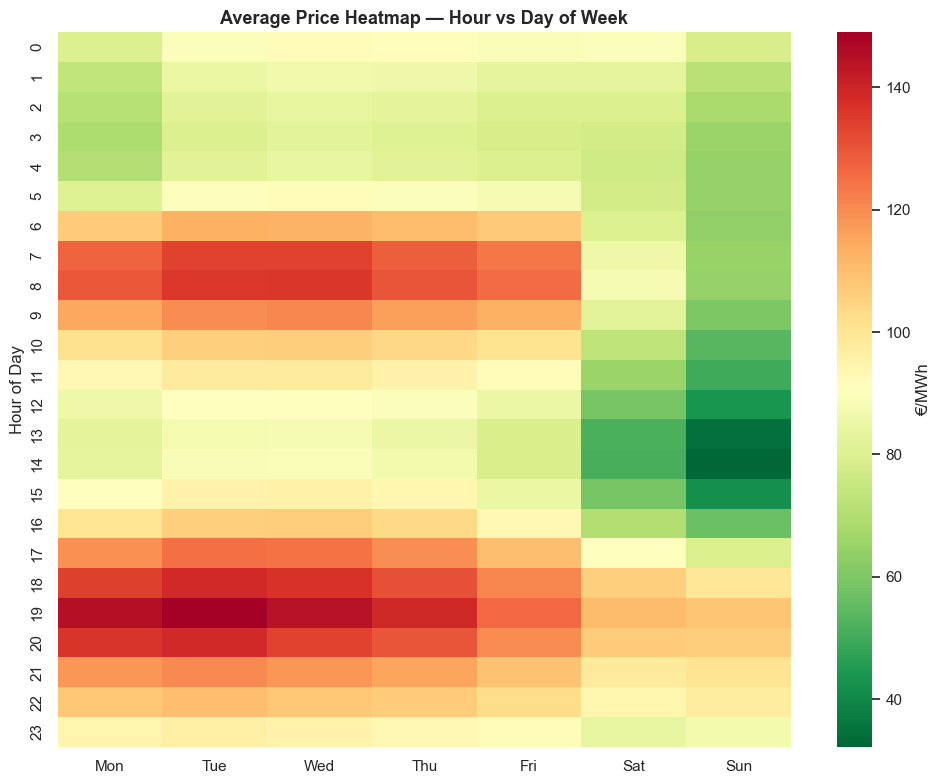

In [9]:
# Heatmap: hour vs day_of_week
pivot = df.pivot_table(values='price', index='hour', columns='day_of_week', aggfunc='mean')
pivot.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10, 8))
sns.heatmap(pivot, cmap='RdYlGn_r', annot=False, fmt='.0f',
            cbar_kws={'label': '€/MWh'})
plt.title('Average Price Heatmap — Hour vs Day of Week', fontsize=13, fontweight='bold')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.show()

---
## 4. Correlation Analysis

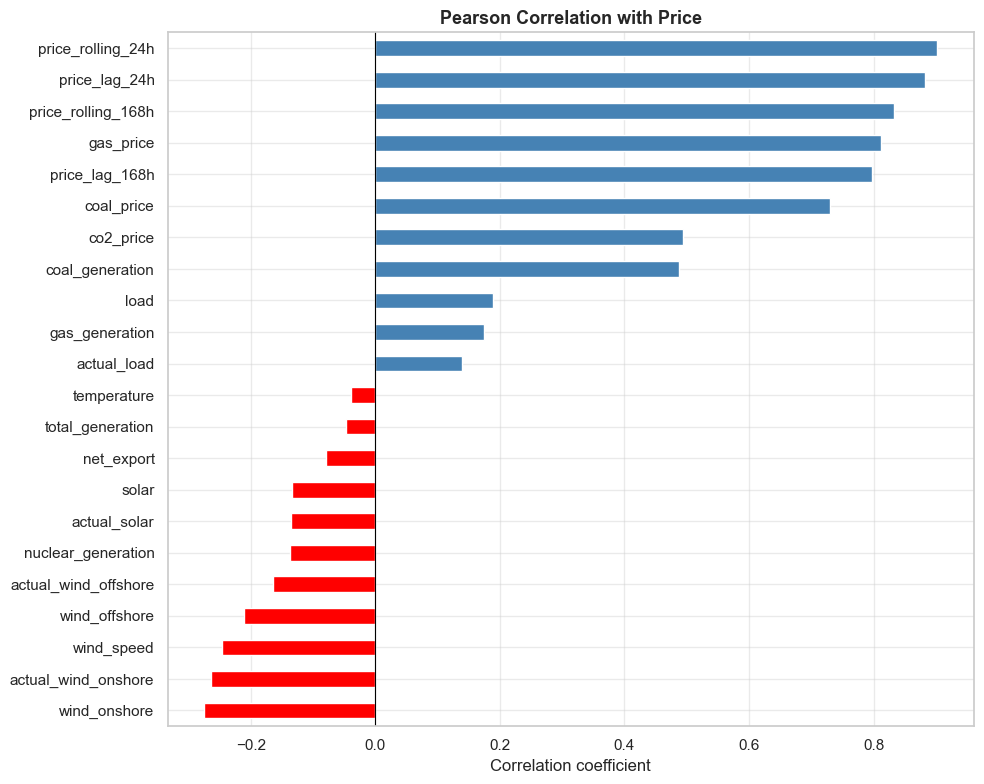

wind_onshore           -0.274
actual_wind_onshore    -0.264
wind_speed             -0.246
wind_offshore          -0.211
actual_wind_offshore   -0.164
nuclear_generation     -0.138
actual_solar           -0.135
solar                  -0.134
net_export             -0.079
total_generation       -0.047
temperature            -0.039
actual_load             0.140
gas_generation          0.175
load                    0.188
coal_generation         0.488
co2_price               0.494
coal_price              0.729
price_lag_168h          0.798
gas_price               0.812
price_rolling_168h      0.833
price_lag_24h           0.882
price_rolling_24h       0.902
Name: price, dtype: float64


In [10]:
# Correlation of all numeric features with price
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['hour', 'day_of_week', 'month']]

corr_with_price = df[num_cols].corr()['price'].drop('price').sort_values()

colors = ['red' if x < 0 else 'steelblue' for x in corr_with_price]
plt.figure(figsize=(10, 8))
corr_with_price.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Pearson Correlation with Price', fontsize=13, fontweight='bold')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

print(corr_with_price.round(3))

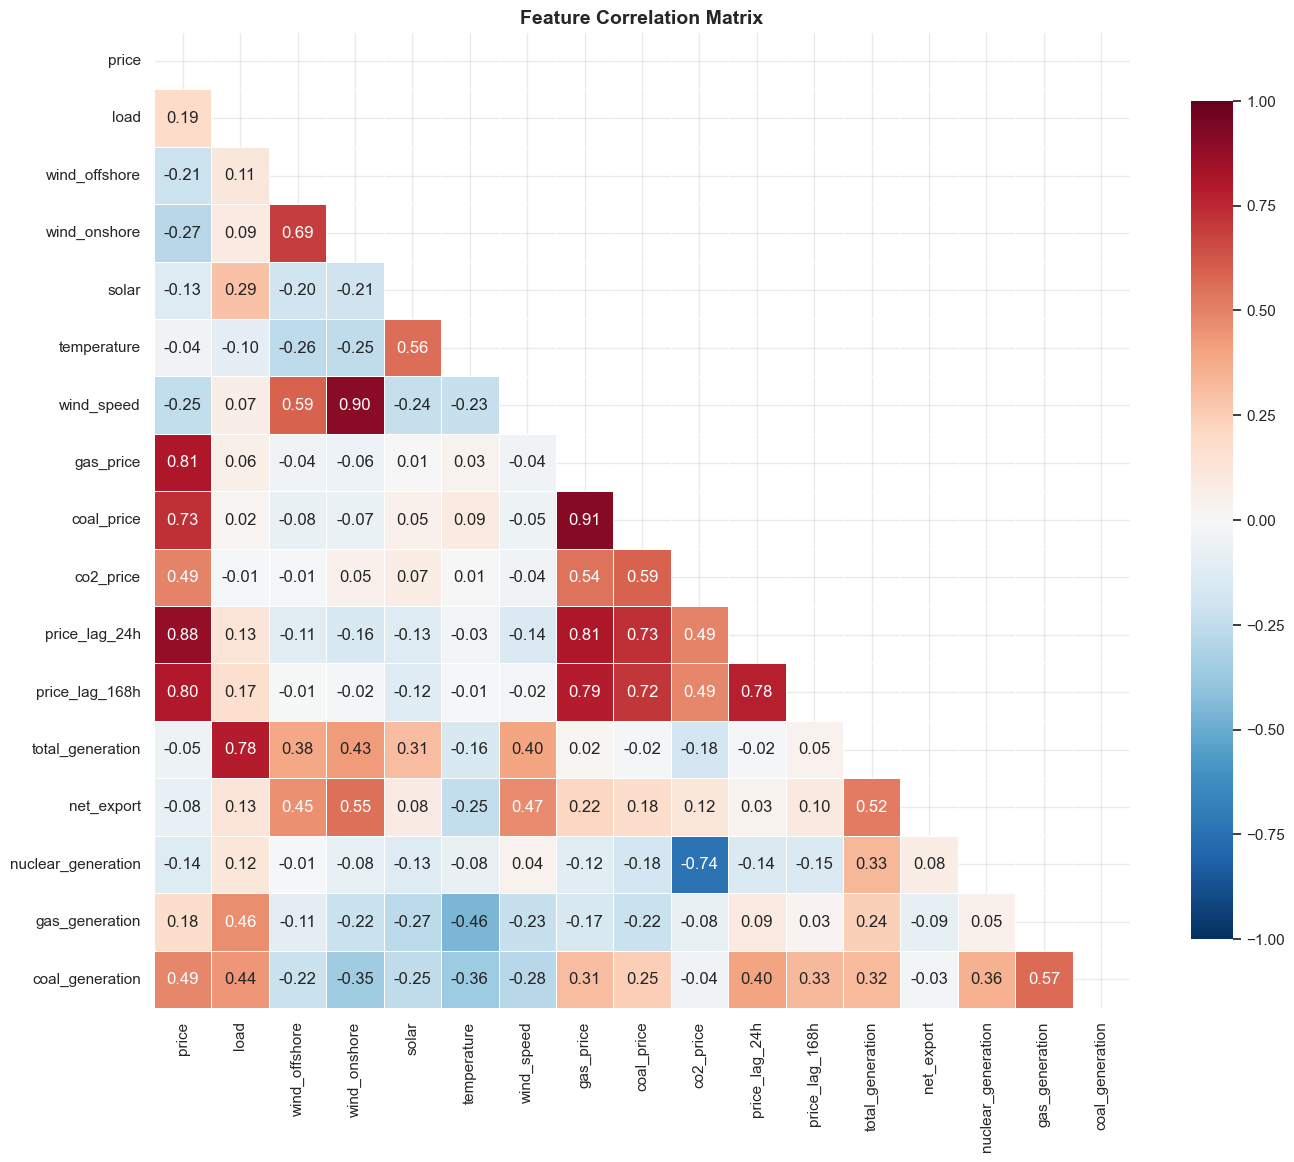

In [11]:
# Full correlation heatmap
key_features = ['price', 'load', 'wind_offshore', 'wind_onshore', 'solar',
                'temperature', 'wind_speed', 'gas_price', 'coal_price', 'co2_price',
                'price_lag_24h', 'price_lag_168h', 'total_generation', 'net_export',
                'nuclear_generation', 'gas_generation', 'coal_generation']

corr_matrix = df[key_features].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
df.columns.tolist()

['timestamp',
 'price',
 'load',
 'wind_offshore',
 'wind_onshore',
 'solar',
 'hour',
 'day_of_week',
 'month',
 'temperature',
 'wind_speed',
 'is_weekend',
 'gas_price',
 'coal_price',
 'price_lag_24h',
 'price_lag_168h',
 'price_rolling_24h',
 'price_rolling_168h',
 'co2_price',
 'is_holiday',
 'is_hol_or_week',
 'total_generation',
 'net_export',
 'coal_generation',
 'gas_generation',
 'nuclear_generation',
 'actual_wind_offshore',
 'actual_wind_onshore',
 'actual_solar',
 'actual_load']

---
## 5. Negative Prices — When and Why

In [13]:
df.columns

Index(['timestamp', 'price', 'load', 'wind_offshore', 'wind_onshore', 'solar',
       'hour', 'day_of_week', 'month', 'temperature', 'wind_speed',
       'is_weekend', 'gas_price', 'coal_price', 'price_lag_24h',
       'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h',
       'co2_price', 'is_holiday', 'is_hol_or_week', 'total_generation',
       'net_export', 'coal_generation', 'gas_generation', 'nuclear_generation',
       'actual_wind_offshore', 'actual_wind_onshore', 'actual_solar',
       'actual_load'],
      dtype='object')

Total negative price hours: 2037 (3.2% of all hours)
Min negative price: -500.00 €/MWh


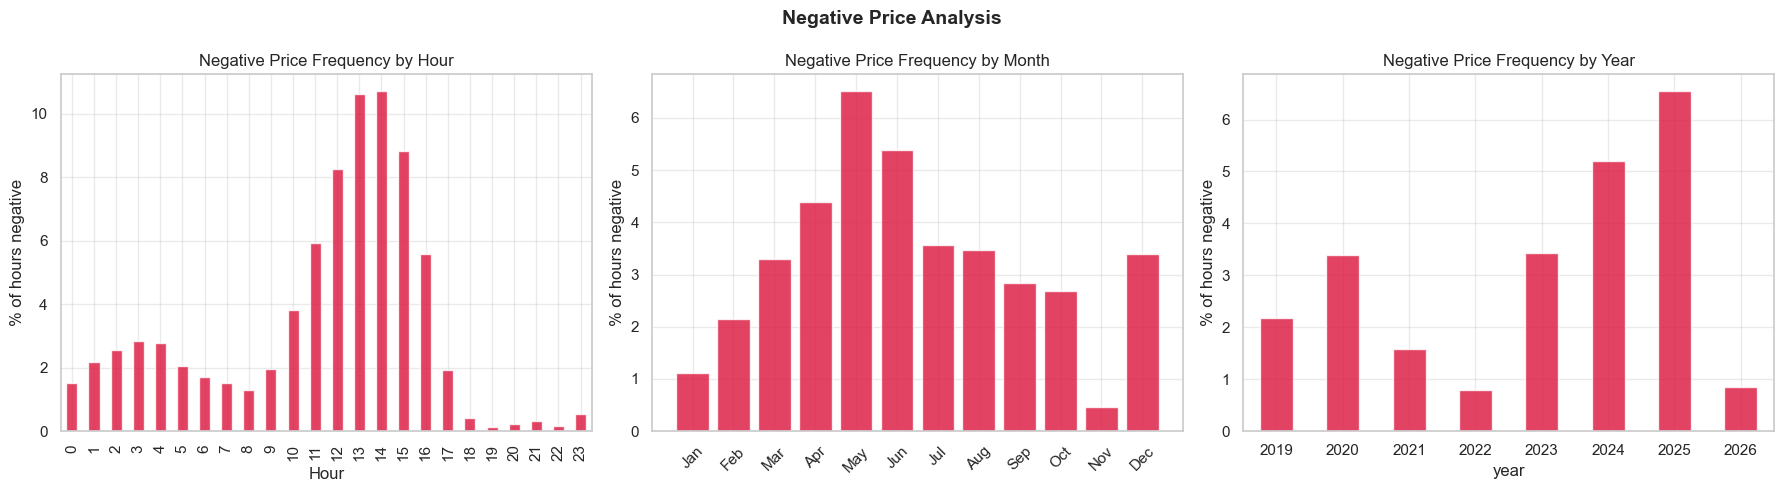

In [14]:
neg = df[df['price'] < 0].copy()
print(f"Total negative price hours: {len(neg)} ({len(neg)/len(df)*100:.1f}% of all hours)")
print(f"Min negative price: {neg['price'].min():.2f} €/MWh")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By hour
neg_hour = neg.groupby('hour').size()
all_hour = df.groupby('hour').size()
(neg_hour / all_hour * 100).plot(kind='bar', ax=axes[0], color='crimson', alpha=0.8)
axes[0].set_title('Negative Price Frequency by Hour')
axes[0].set_ylabel('% of hours negative')
axes[0].set_xlabel('Hour')

# By month
neg_month = neg.groupby('month').size()
all_month = df.groupby('month').size()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
neg_pct = (neg_month / all_month * 100).reindex(range(1, 13), fill_value=0)
axes[1].bar(month_labels, neg_pct.values, color='crimson', alpha=0.8)
axes[1].set_title('Negative Price Frequency by Month')
axes[1].set_ylabel('% of hours negative')
axes[1].tick_params(axis='x', rotation=45)

# By year
neg['year'] = neg['timestamp'].dt.year
df['year'] = df['timestamp'].dt.year
neg_year = neg.groupby('year').size()
all_year = df.groupby('year').size()
(neg_year / all_year * 100).plot(kind='bar', ax=axes[2], color='crimson', alpha=0.8)
axes[2].set_title('Negative Price Frequency by Year')
axes[2].set_ylabel('% of hours negative')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Negative Price Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# What drives negative prices? Compare neg vs pos
features_to_compare = ['solar', 'wind_onshore', 'wind_offshore', 'nuclear_generation',
                        'load', 'total_generation', 'net_export']

df['price_sign'] = np.where(df['price'] < 0, 'Negative', 'Positive')
compare = df.groupby('price_sign')[features_to_compare].mean().T
compare['diff_%'] = ((compare['Negative'] - compare['Positive']) / compare['Positive'] * 100).round(1)
print("Feature averages: Negative vs Positive prices")
print(compare.round(1))

Feature averages: Negative vs Positive prices
price_sign          Negative  Positive  diff_%
solar                20556.0    5696.5   260.9
wind_onshore         21192.4   11626.7    82.3
wind_offshore         3416.5    2883.6    18.5
nuclear_generation    2021.0    3811.3   -47.0
load                 49612.5   54452.8    -8.9
total_generation     60299.7   54767.7    10.1
net_export           19433.6   12305.7    57.9


---
## 6. Forecast vs Actual (Forecast Errors)

Wind Offshore        → MAE:      489  RMSE:      692  Bias: +10
Wind Onshore         → MAE:     1107  RMSE:     1549  Bias: +76
Solar                → MAE:      452  RMSE:      950  Bias: -4
Load                 → MAE:     2081  RMSE:     2637  Bias: +594


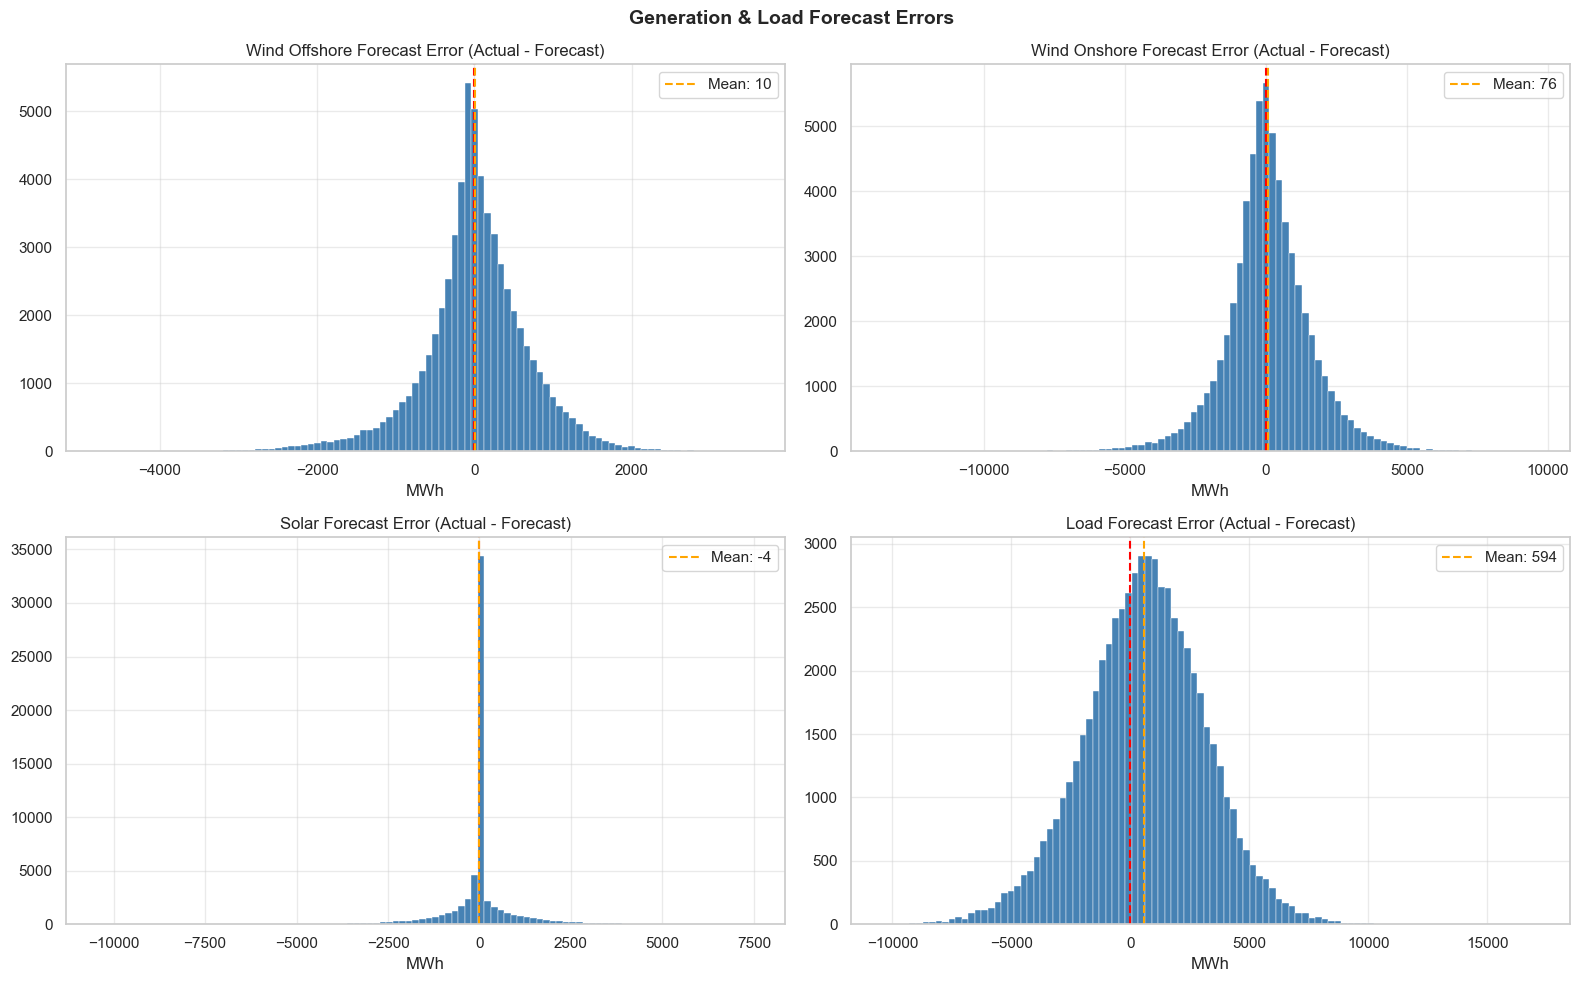

In [16]:
df['err_wind_offshore'] = df['actual_wind_offshore'] - df['wind_offshore']
df['err_wind_onshore']  = df['actual_wind_onshore']  - df['wind_onshore']
df['err_solar']         = df['actual_solar']         - df['solar']
df['err_load']          = df['actual_load']          - df['load']

errors = {
    'Wind Offshore': df['err_wind_offshore'],
    'Wind Onshore':  df['err_wind_onshore'],
    'Solar':         df['err_solar'],
    'Load':          df['err_load']
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (name, err) in enumerate(errors.items()):
    axes[i].hist(err, bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[i].axvline(0, color='red', linestyle='--')
    axes[i].axvline(err.mean(), color='orange', linestyle='--', label=f'Mean: {err.mean():.0f}')
    axes[i].set_title(f'{name} Forecast Error (Actual - Forecast)')
    axes[i].set_xlabel('MWh')
    axes[i].legend()
    
    mae = err.abs().mean()
    rmse = np.sqrt((err**2).mean())
    bias = err.mean()
    print(f"{name:20s} → MAE: {mae:8.0f}  RMSE: {rmse:8.0f}  Bias: {bias:+.0f}")

plt.suptitle('Generation & Load Forecast Errors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

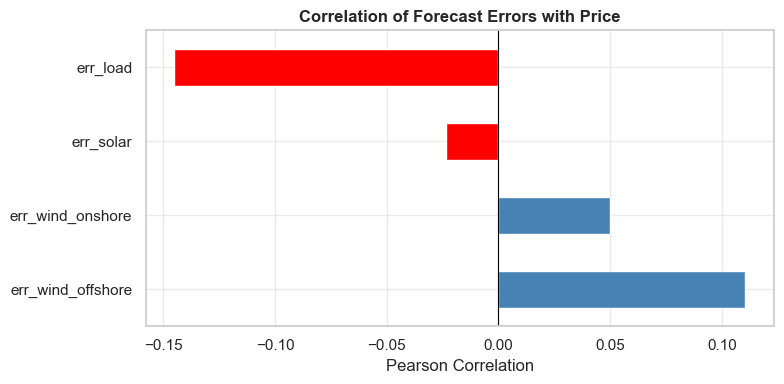

err_wind_offshore    0.1106
err_wind_onshore     0.0499
err_solar           -0.0237
err_load            -0.1452
Name: price, dtype: float64


In [17]:
# Do forecast errors correlate with price?
err_cols = ['err_wind_offshore', 'err_wind_onshore', 'err_solar', 'err_load']
corr_err = df[err_cols + ['price']].corr()['price'].drop('price')

colors = ['red' if x < 0 else 'steelblue' for x in corr_err]
plt.figure(figsize=(8, 4))
corr_err.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Forecast Errors with Price', fontsize=12, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print(corr_err.round(4))

---
## 7. Key Feature Scatter Plots vs Price

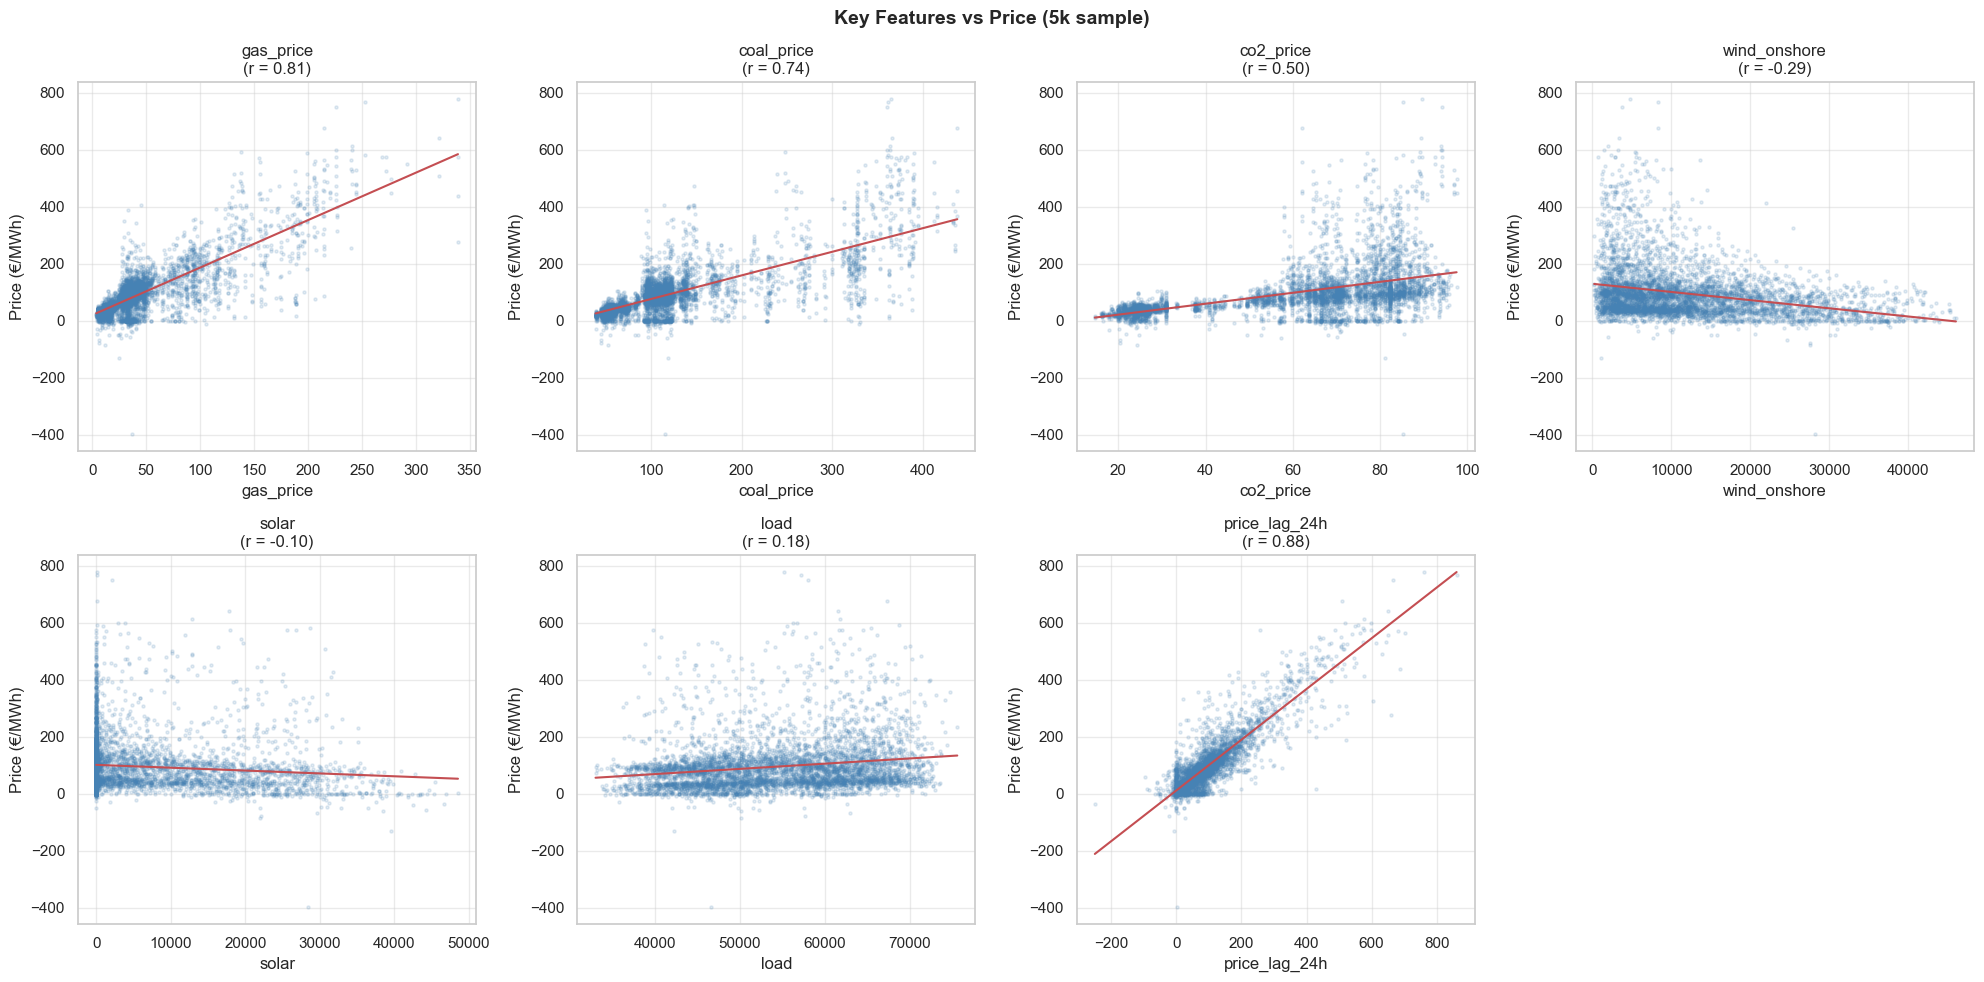

In [18]:
key_features_scatter = ['gas_price', 'coal_price', 'co2_price',
                         'wind_onshore', 'solar', 'load', 'price_lag_24h']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Sample for performance
sample = df.sample(5000, random_state=42)

for i, feat in enumerate(key_features_scatter):
    axes[i].scatter(sample[feat], sample['price'], alpha=0.15, s=5, color='steelblue')
    # Add trend line
    z = np.polyfit(sample[feat].dropna(), sample.loc[sample[feat].notna(), 'price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[feat].min(), sample[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r-', linewidth=1.5)
    corr = sample[feat].corr(sample['price'])
    axes[i].set_title(f'{feat}\n(r = {corr:.2f})')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Price (€/MWh)')

axes[-1].axis('off')
plt.suptitle('Key Features vs Price (5k sample)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Price Volatility Over Time

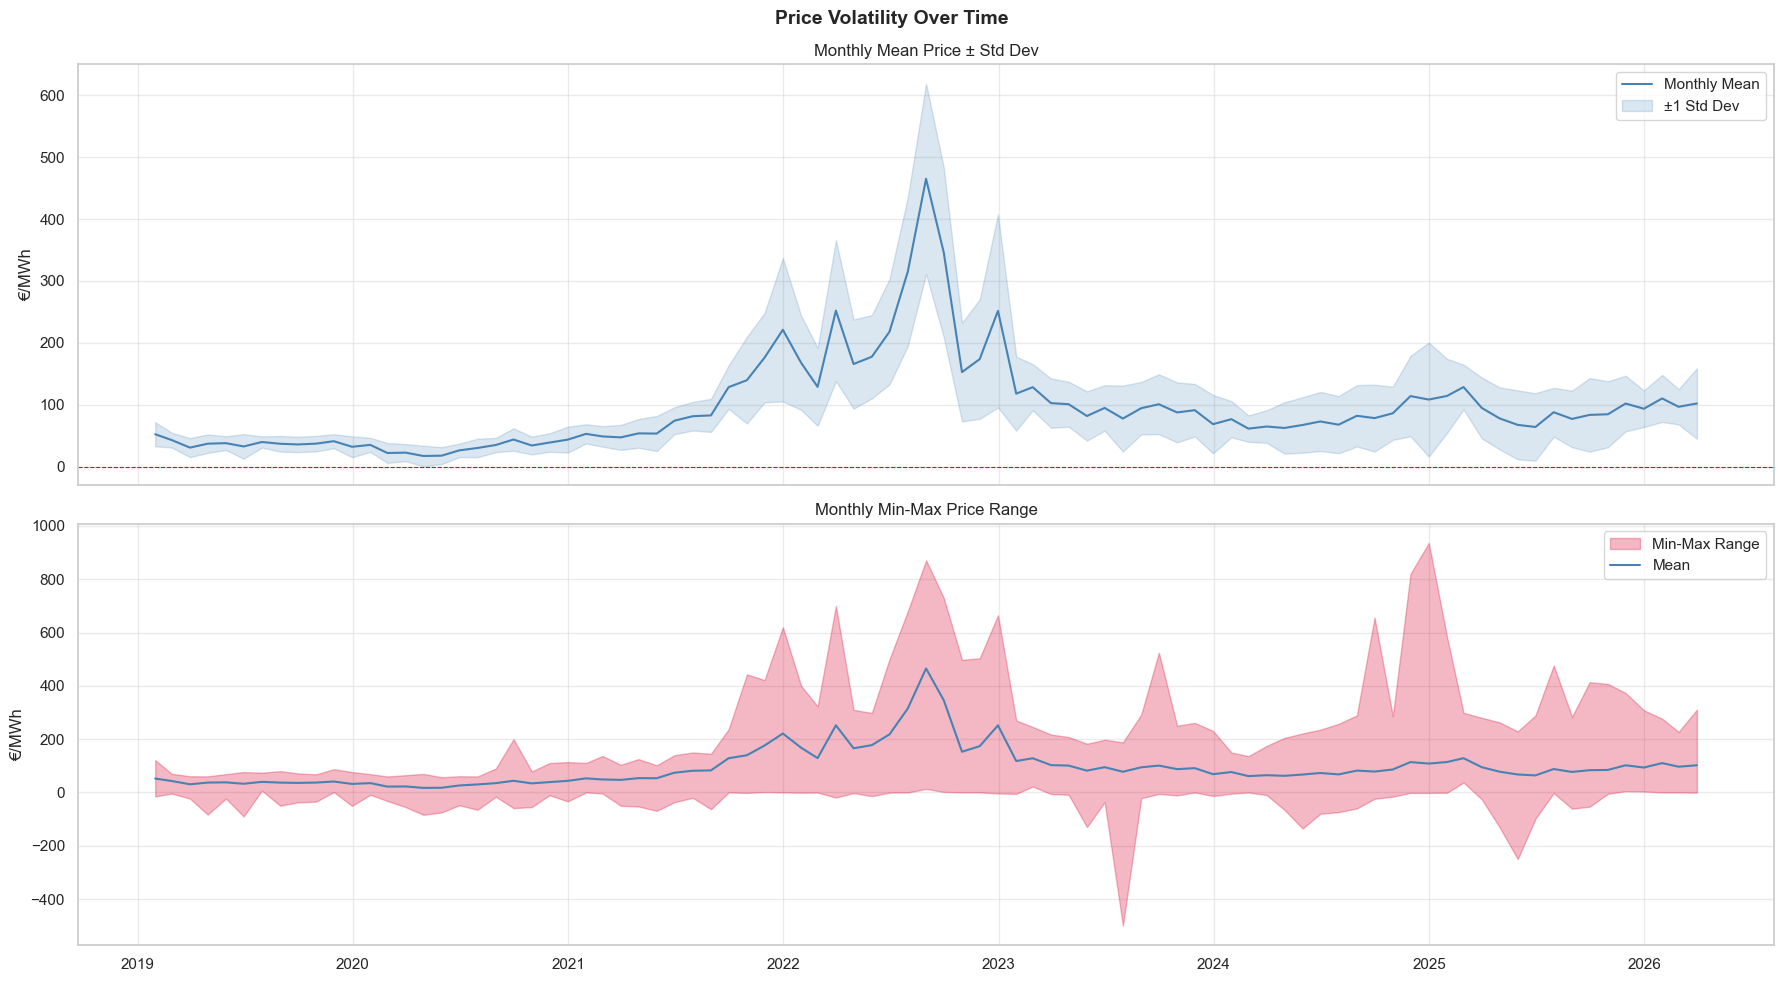

In [19]:
# Monthly stats
monthly = df.set_index('timestamp').resample('M')['price'].agg(['mean', 'std', 'min', 'max'])

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Mean with std band
axes[0].plot(monthly.index, monthly['mean'], color='steelblue', linewidth=1.5, label='Monthly Mean')
axes[0].fill_between(monthly.index,
                     monthly['mean'] - monthly['std'],
                     monthly['mean'] + monthly['std'],
                     alpha=0.2, color='steelblue', label='±1 Std Dev')
axes[0].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[0].set_title('Monthly Mean Price ± Std Dev')
axes[0].set_ylabel('€/MWh')
axes[0].legend()

# Min/Max range
axes[1].fill_between(monthly.index, monthly['min'], monthly['max'],
                     alpha=0.3, color='crimson', label='Min-Max Range')
axes[1].plot(monthly.index, monthly['mean'], color='steelblue', linewidth=1.5, label='Mean')
axes[1].set_title('Monthly Min-Max Price Range')
axes[1].set_ylabel('€/MWh')
axes[1].legend()

axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.suptitle('Price Volatility Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Fuel Price Dynamics

C:\Users\Josip\AppData\Local\Temp\ipykernel_21224\3952562724.py:20: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
c:\Users\Josip\Desktop\Data science and AI\Lectures\Week12\Clustering\ds-clustering\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


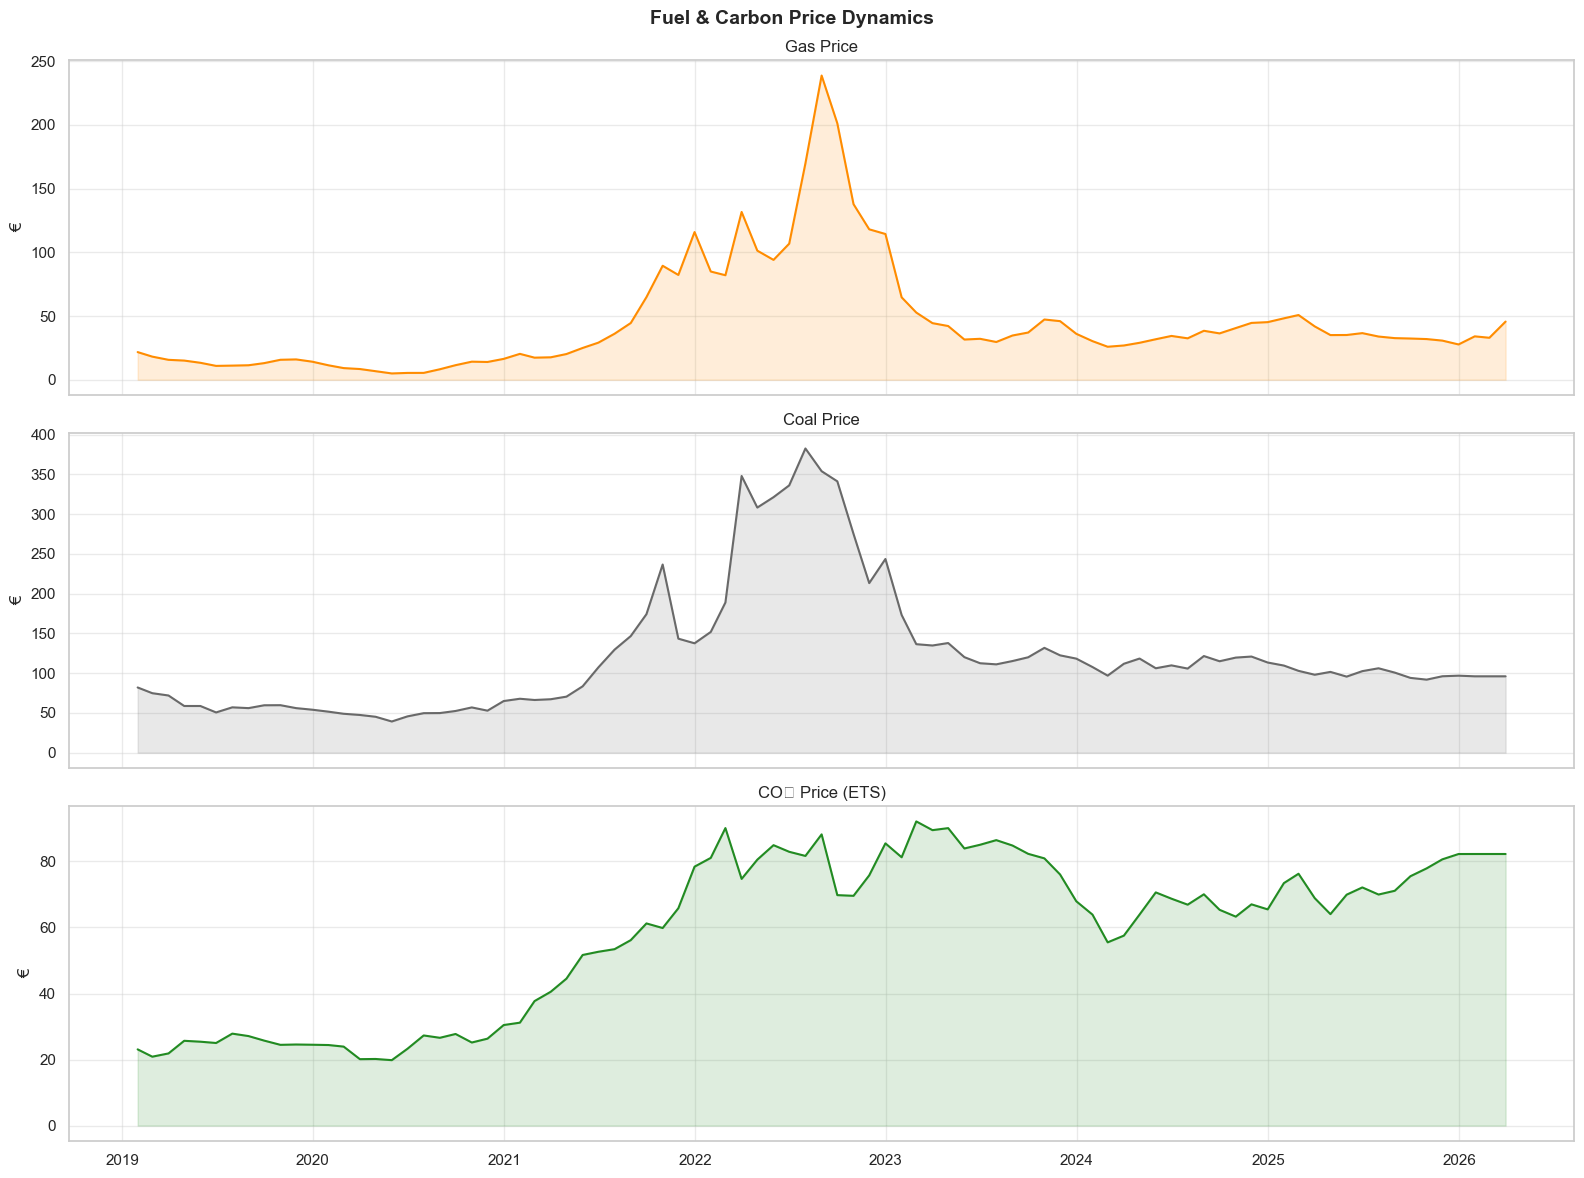

In [20]:
fuel_monthly = df.set_index('timestamp')[['gas_price', 'coal_price', 'co2_price']].resample('M').mean()

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

fuel_info = [
    ('gas_price', 'Gas Price', 'darkorange'),
    ('coal_price', 'Coal Price', 'dimgray'),
    ('co2_price', 'CO₂ Price (ETS)', 'forestgreen'),
]

for ax, (col, label, color) in zip(axes, fuel_info):
    ax.plot(fuel_monthly.index, fuel_monthly[col], color=color, linewidth=1.5)
    ax.fill_between(fuel_monthly.index, fuel_monthly[col], alpha=0.15, color=color)
    ax.set_title(label)
    ax.set_ylabel('€')

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.suptitle('Fuel & Carbon Price Dynamics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. EDA Summary

In [21]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print(f"""
DATASET
  Rows:     {len(df):,}
  Period:   {df.timestamp.min().date()} → {df.timestamp.max().date()}
  Market:   Germany/Luxembourg day-ahead

PRICE
  Mean:     {df.price.mean():.1f} €/MWh
  Median:   {df.price.median():.1f} €/MWh
  Std:      {df.price.std():.1f} €/MWh
  Min:      {df.price.min():.1f} €/MWh
  Max:      {df.price.max():.1f} €/MWh
  Negative: {(df.price < 0).sum():,} hours ({(df.price < 0).mean()*100:.1f}%)

STRONGEST CORRELATIONS WITH PRICE
  Positive: gas_price, coal_price, co2_price, price_lag_24h
  Negative: wind_onshore, wind_offshore, solar, nuclear

KEY OBSERVATIONS
  - Clear energy crisis spike in 2021-2023
  - Strong intraday pattern (morning/evening peaks)
  - Weekends ~10-15% cheaper than weekdays
  
  - Negative prices concentrated in midday hours (high solar)
  - Lag features (24h, 168h) are among the best predictors
  - Gas price is the single strongest correlated fuel
""")

EDA SUMMARY

DATASET
  Rows:     62,728
  Period:   2019-01-08 → 2026-03-05
  Market:   Germany/Luxembourg day-ahead

PRICE
  Mean:     95.1 €/MWh
  Median:   75.9 €/MWh
  Std:      92.9 €/MWh
  Min:      -500.0 €/MWh
  Max:      936.3 €/MWh
  Negative: 2,037 hours (3.2%)

STRONGEST CORRELATIONS WITH PRICE
  Positive: gas_price, coal_price, co2_price, price_lag_24h
  Negative: wind_onshore, wind_offshore, solar, nuclear

KEY OBSERVATIONS
  - Clear energy crisis spike in 2021-2023
  - Strong intraday pattern (morning/evening peaks)
  - Weekends ~10-15% cheaper than weekdays

  - Negative prices concentrated in midday hours (high solar)
  - Lag features (24h, 168h) are among the best predictors
  - Gas price is the single strongest correlated fuel



In [22]:
print(df['net_export'].isnull().sum())


0


In [23]:
# Missing values
print("=== NET_EXPORT MISSING VALUES ===")
print(df['net_export'].isnull().sum())

# Duplicates
print("\n=== DUPLICATES ===")
print(f"Duplicate rows (all columns): {df.duplicated().sum()}")
print(f"Duplicate timestamps: {df['timestamp'].duplicated().sum()}")

# Bonus - net_export basic stats
print("\n=== NET_EXPORT STATS ===")
print(df['net_export'].describe().round(2))

=== NET_EXPORT MISSING VALUES ===
0

=== DUPLICATES ===
Duplicate rows (all columns): 0
Duplicate timestamps: 0

=== NET_EXPORT STATS ===
count    62728.00
mean     12537.20
std       5905.91
min        521.86
25%       8251.54
50%      11647.09
75%      16193.52
max      37701.71
Name: net_export, dtype: float64


In [24]:
df.columns.tolist()

['timestamp',
 'price',
 'load',
 'wind_offshore',
 'wind_onshore',
 'solar',
 'hour',
 'day_of_week',
 'month',
 'temperature',
 'wind_speed',
 'is_weekend',
 'gas_price',
 'coal_price',
 'price_lag_24h',
 'price_lag_168h',
 'price_rolling_24h',
 'price_rolling_168h',
 'co2_price',
 'is_holiday',
 'is_hol_or_week',
 'total_generation',
 'net_export',
 'coal_generation',
 'gas_generation',
 'nuclear_generation',
 'actual_wind_offshore',
 'actual_wind_onshore',
 'actual_solar',
 'actual_load',
 'year',
 'price_sign',
 'err_wind_offshore',
 'err_wind_onshore',
 'err_solar',
 'err_load']

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62728 entries, 0 to 62727
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             62728 non-null  datetime64[ns]
 1   price                 62728 non-null  float64       
 2   load                  62728 non-null  float64       
 3   wind_offshore         62728 non-null  float64       
 4   wind_onshore          62728 non-null  float64       
 5   solar                 62728 non-null  float64       
 6   hour                  62728 non-null  int64         
 7   day_of_week           62728 non-null  int64         
 8   month                 62728 non-null  int64         
 9   temperature           62728 non-null  float64       
 10  wind_speed            62728 non-null  float64       
 11  is_weekend            62728 non-null  bool          
 12  gas_price             62728 non-null  float64       
 13  coal_price      

In [39]:
df['err_load'].unique()

array([ 2870.  ,  2726.75,  2417.  , ..., -1074.15,  -853.03,  -953.4 ])